# Trabajo Práctico II - Predicción de Puntuación y Capitalización
## Aprendizaje Automático II - DC, UBA

# 1. Importaciones y configuración


In [27]:
# ==================================================================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN
# ==================================================================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.cuda.amp import GradScaler, autocast  # Para Mixed Precision (Velocidad)
from transformers import BertTokenizer, BertModel
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report
import re
import time
import os
import gdown
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Configuración del dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Hardware detectado: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Hiperparámetros Globales
BATCH_SIZE = 64         # Aumentado gracias a la optimización de memoria
HIDDEN_DIM = 256        # Sweet spot para este problema
NUM_LAYERS = 2          # Capas de la LSTM
DROPOUT = 0.3
LEARNING_RATE = 1e-4
EPOCHS = 10              # Ajustable según tiempo
N_ROWS = 300_000        # Cantidad de filas a procesar (o None para todo)

# Constantes del Problema
PUNTUACIONES_INICIALES = {"¿": 1}
PUNTUACIONES_FINALES = {".": 1, ",": 2, "?": 3}
MODEL_NAME = 'bert-base-multilingual-cased'

🚀 Hardware detectado: cuda
   GPU: NVIDIA A40


# 2. CARGA DE RECURSOS (Tokenizer y Matriz de Embeddings)


In [28]:
print("\n📥 Cargando BERT Tokenizer y Pesos...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
bert_base = BertModel.from_pretrained(MODEL_NAME)

# TRUCO DE INGENIERÍA:
# Extraemos la matriz de pesos de los embeddings de BERT (VocabSize x 768).
# Usaremos esto como una "Lookup Table" en nuestro modelo en lugar de pasar
# cada texto por el modelo BERT completo. Esto ahorra muchísima VRAM y cómputo.
bert_embedding_matrix = bert_base.embeddings.word_embeddings.weight.clone().detach()
print(f"✅ Matriz de Embeddings extraída: {bert_embedding_matrix.shape} (Se usará congelada)")

del bert_base # Liberamos la memoria del modelo BERT base, ya no lo necesitamos


📥 Cargando BERT Tokenizer y Pesos...
✅ Matriz de Embeddings extraída: torch.Size([119547, 768]) (Se usará congelada)


# 3. DESCARGA Y CARGA DE DATOS


In [29]:
# ==================================================================================================
# 3. DESCARGA Y CARGA DE DATOS
# ==================================================================================================
csv_path = "archivo.csv"
if not os.path.exists(csv_path):
    print("\n⬇️ Descargando dataset...")
    # ID del archivo proporcionado en tu contexto
    file_id = "1XeL2Cc5YPWB8Bc84515LexAsca46dhAb" 
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, csv_path, quiet=False)

print("\n📖 Leyendo CSV (Optimizando memoria)...")
# Leemos solo las columnas necesarias
df = pd.read_csv(csv_path, usecols=['text'], nrows=N_ROWS).rename(columns={'text': 'texto'})
df = df.reset_index().rename(columns={'index': 'instancia_id'})
print(f"✅ Datos cargados: {len(df)} filas")


📖 Leyendo CSV (Optimizando memoria)...
✅ Datos cargados: 300000 filas


# 4. LÓGICA DE PREPROCESAMIENTO EFICIENTE (CPU)


In [30]:
# ==================================================================================================
# 4. LÓGICA DE PREPROCESAMIENTO EFICIENTE (CPU)
# ==================================================================================================
def clasificar_capitalizacion(palabra):
    if palabra.isupper() and len(palabra) > 1: return 3
    if palabra and palabra[0].isupper() and palabra[1:].islower(): return 1
    if re.search(r"[A-Z].*[a-z]|[a-z].*[A-Z]", palabra) or re.search(r"\d|[^a-zA-ZáéíóúÁÉÍÓÚñÑ]", palabra): return 2
    return 0

def procesar_texto_a_ids(textos, ids):
    """
    Convierte texto crudo a listas de Token IDs y Etiquetas.
    NO genera embeddings aquí, solo enteros (muy liviano).
    """
    data_batch = []
    
    for texto, inst_id in zip(textos, ids):
        # 1. Separar palabras y signos
        if not isinstance(texto, str): continue
        elementos = re.findall(r"[¿?,\.]|[^\s¿?,\.]+", texto)
        
        # 2. Generar etiquetas a nivel de palabra
        palabras_info = []
        punt_inicial = 0
        
        for elem in elementos:
            if elem in PUNTUACIONES_INICIALES:
                punt_inicial = PUNTUACIONES_INICIALES[elem]
            elif elem in PUNTUACIONES_FINALES:
                if palabras_info:
                    palabras_info[-1]["pf"] = PUNTUACIONES_FINALES[elem]
            else:
                palabras_info.append({
                    "word": elem,
                    "pi": punt_inicial,
                    "pf": 0,
                    "cap": clasificar_capitalizacion(elem)
                })
                punt_inicial = 0 # Reset

        if not palabras_info: continue

        # 3. Alinear con Tokenizer (Manejo de sub-tokens ##)
        instancia_data = {
            "x_ids": [], # Input
            "y_pi": [],  # Targets
            "y_pf": [],
            "y_cap": []
        }
        
        for info in palabras_info:
            # Tokenizamos la palabra en minúscula (el modelo es cased, pero normalizamos entrada)
            # Nota: Para capitalización, el target 'y_cap' ya tiene la info real.
            word_lower = info["word"].lower()
            subtokens = tokenizer.tokenize(word_lower)
            ids = tokenizer.convert_tokens_to_ids(subtokens)
            
            for j, tid in enumerate(ids):
                instancia_data["x_ids"].append(tid)
                
                # Lógica de propagación de etiquetas a subtokens:
                # PI: Solo al primer subtoken.
                # PF: Solo al último subtoken.
                # CAP: A todos los subtokens (según consigna original).
                instancia_data["y_pi"].append(info["pi"] if j == 0 else 0)
                instancia_data["y_pf"].append(info["pf"] if j == len(ids)-1 else 0)
                instancia_data["y_cap"].append(info["cap"])
        
        if instancia_data["x_ids"]:
            data_batch.append(instancia_data)
            
    return data_batch

def generar_dataset_en_memoria(dataframe, batch_size=10000):
    all_data = []
    total = len(dataframe)
    print(f"⚙️  Procesando {total} textos para generar dataset numérico...")
    start = time.time()
    
    # Iteramos por chunks para no bloquear la CPU
    for i in range(0, total, batch_size):
        chunk = dataframe.iloc[i : i + batch_size]
        textos = chunk['texto'].tolist()
        ids = chunk['instancia_id'].tolist()
        
        batch_procesado = procesar_texto_a_ids(textos, ids)
        all_data.extend(batch_procesado)
        
        if (i + batch_size) % 50000 == 0:
             print(f"   -> Progreso: {min(i + batch_size, total)}/{total} ({(time.time()-start):.1f}s)")
             
    print(f"✅ Dataset listo en memoria RAM (Formato eficiente). Total secuencias: {len(all_data)}")
    return all_data

# Generamos la lista de diccionarios (muy rápida)
data_list = generar_dataset_en_memoria(df)

⚙️  Procesando 300000 textos para generar dataset numérico...
   -> Progreso: 50000/300000 (40.3s)
   -> Progreso: 100000/300000 (81.3s)
   -> Progreso: 150000/300000 (120.7s)
   -> Progreso: 200000/300000 (161.4s)
   -> Progreso: 250000/300000 (200.8s)
   -> Progreso: 300000/300000 (239.8s)
✅ Dataset listo en memoria RAM (Formato eficiente). Total secuencias: 300000


# 5. CÁLCULO DE PESOS (Class Weights)


In [31]:
# ==================================================================================================
# 5. CÁLCULO DE PESOS (Class Weights)
# ==================================================================================================
def calcular_pesos(data_list, device):
    print("\n⚖️  Calculando pesos de clases...")
    # Generadores para no duplicar memoria
    y_pi_all = [y for item in data_list for y in item['y_pi']]
    y_pf_all = [y for item in data_list for y in item['y_pf']]
    y_cap_all = [y for item in data_list for y in item['y_cap']]
    
    def get_w(y_flat):
        classes = np.unique(y_flat)
        # Usamos 'balanced' para dar más peso a las clases raras
        weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_flat)
        # Suavizamos con sqrt y clip para que no sean tan explosivos
        weights = np.sqrt(weights)
        weights = np.clip(weights, 1.0, 50.0)
        return torch.tensor(weights, dtype=torch.float32).to(device)

    w_pi = get_w(y_pi_all)
    w_pf = get_w(y_pf_all)
    w_cap = get_w(y_cap_all)
    
    print(f"   Pesos PI: {w_pi.cpu().numpy()}")
    print(f"   Pesos PF: {w_pf.cpu().numpy()}")
    print(f"   Pesos Cap: {w_cap.cpu().numpy()}")
    return w_pi, w_pf, w_cap

weights_pi, weights_pf, weights_cap = calcular_pesos(data_list, device)


⚖️  Calculando pesos de clases...
   Pesos PI: [ 1.      17.06976]
   Pesos PF: [ 1.         2.550301   2.4735851 12.353414 ]
   Pesos Cap: [1.        1.6653758 4.962415  8.097757 ]


# 6. DATASET Y DATALOADER DE PYTORCH


In [32]:
# ==================================================================================================
# 6. DATASET Y DATALOADER DE PYTORCH
# ==================================================================================================
class OptimizedDataset(Dataset):
    def __init__(self, data):
        self.data = data
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Convertimos a tensores Long (Enteros) aquí, no floats
        item = self.data[idx]
        return {
            "x": torch.tensor(item["x_ids"], dtype=torch.long),
            "y_pi": torch.tensor(item["y_pi"], dtype=torch.long),
            "y_pf": torch.tensor(item["y_pf"], dtype=torch.long),
            "y_cap": torch.tensor(item["y_cap"], dtype=torch.long),
            "len": len(item["x_ids"])
        }

def collate_fn(batch):
    # Ordenar por longitud para pack_padded_sequence (necesario en LSTMs)
    batch.sort(key=lambda x: x['len'], reverse=True)
    
    x = [item['x'] for item in batch]
    y_pi = [item['y_pi'] for item in batch]
    y_pf = [item['y_pf'] for item in batch]
    y_cap = [item['y_cap'] for item in batch]
    lengths = torch.tensor([item['len'] for item in batch])
    
    # Padding
    x_pad = pad_sequence(x, batch_first=True, padding_value=0)
    y_pi_pad = pad_sequence(y_pi, batch_first=True, padding_value=-100) # -100 se ignora en CrossEntropy
    y_pf_pad = pad_sequence(y_pf, batch_first=True, padding_value=-100)
    y_cap_pad = pad_sequence(y_cap, batch_first=True, padding_value=-100)
    
    return x_pad, y_pi_pad, y_pf_pad, y_cap_pad, lengths

# Split Train/Val
train_size = int(0.9 * len(data_list))
val_size = len(data_list) - train_size
train_data, val_data = random_split(OptimizedDataset(data_list), [train_size, val_size], 
                                    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
print(f"\n✅ Dataloaders listos. Train Batches: {len(train_loader)}")


✅ Dataloaders listos. Train Batches: 4219


# 7. MODELO RNN con LSTM (Lookup Embedding)


In [33]:
# ==================================================================================================
# 7. MODELO OPTIMIZADO (BiLSTM con Lookup Embedding)
# ==================================================================================================
class RNN_LSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, n_pi, n_pf, n_cap, dropout):
        super(RNN_LSTM, self).__init__()
        
        # 1. Embedding Layer (Congelada)
        # Esto reemplaza a llamar a BERT externamente. Es muchísimo más rápido.
        rows, cols = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True, padding_idx=0)
        
        # 2. LSTM Bidireccional
        self.lstm = nn.LSTM(
            input_size=cols, # 768
            hidden_size=hidden_dim,
            num_layers=NUM_LAYERS,
            batch_first=True,
            bidirectional=False,
            dropout=dropout
        )
        
        # 3. Dropout y Clasificadores
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim
        
        self.fc_pi = nn.Linear(out_dim, n_pi)
        self.fc_pf = nn.Linear(out_dim, n_pf)
        self.fc_cap = nn.Linear(out_dim, n_cap)

    def forward(self, x, lengths):
        # x: (Batch, Seq) -> IDs enteros
        
        # 1. Lookup (Rápido en GPU)
        embeds = self.embedding(x) # (Batch, Seq, 768)
        
        # 2. Pack
        # lengths debe estar en CPU para pack_padded
        packed_input = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=True)
        
        # 3. LSTM
        packed_output, _ = self.lstm(packed_input)
        
        # 4. Unpack
        rnn_out, _ = pad_packed_sequence(packed_output, batch_first=True)
        
        # 5. Predict
        rnn_out = self.dropout(rnn_out)
        
        return self.fc_pi(rnn_out), self.fc_pf(rnn_out), self.fc_cap(rnn_out)

# Instanciar modelo
model = RNN_LSTM(
    embedding_matrix=bert_embedding_matrix, 
    hidden_dim=HIDDEN_DIM, 
    n_pi=len(PUNTUACIONES_INICIALES)+1, # +1 por la clase 0
    n_pf=len(PUNTUACIONES_FINALES)+1, 
    n_cap=4, 
    dropout=DROPOUT
)

model_RNN = model #para visualizar predicciones luego

model.to(device)

RNN_LSTM(
  (embedding): Embedding(119547, 768, padding_idx=0)
  (lstm): LSTM(768, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_pi): Linear(in_features=256, out_features=2, bias=True)
  (fc_pf): Linear(in_features=256, out_features=4, bias=True)
  (fc_cap): Linear(in_features=256, out_features=4, bias=True)
)

## Entrenamiento

In [34]:
# ==================================================================================================
# 8. ENTRENAMIENTO (Con Métricas Detalladas y Guardado de Plots)
# ==================================================================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scaler = GradScaler() 

# Loss functions
crit_pi = nn.CrossEntropyLoss(weight=weights_pi, ignore_index=-100, label_smoothing=0.05)
crit_pf = nn.CrossEntropyLoss(weight=weights_pf, ignore_index=-100, label_smoothing=0.05)
crit_cap = nn.CrossEntropyLoss(weight=weights_cap, ignore_index=-100, label_smoothing=0.05)

def train_epoch(loader):
    model.train()
    total_loss = 0
    
    for i, (x, y_pi, y_pf, y_cap, lens) in enumerate(loader):
        x, y_pi, y_pf, y_cap = x.to(device), y_pi.to(device), y_pf.to(device), y_cap.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            out_pi, out_pf, out_cap = model(x, lens)
            
            l1 = crit_pi(out_pi.view(-1, out_pi.shape[-1]), y_pi.view(-1))
            l2 = crit_pf(out_pf.view(-1, out_pf.shape[-1]), y_pf.view(-1))
            l3 = crit_cap(out_cap.view(-1, out_cap.shape[-1]), y_cap.view(-1))
            
            loss = l1 + l2 + l3
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        if i % 50 == 0:
            print(f"   Batch {i}/{len(loader)} - Loss: {loss.item():.4f}", end='\r')
            
    return total_loss / len(loader)

def validate_detailed(loader):
    model.eval()
    total_loss = 0
    
    # Listas para almacenar predicciones y targets de las 3 tareas
    lists = {
        "pi_true": [], "pi_pred": [],
        "pf_true": [], "pf_pred": [],
        "cap_true": [], "cap_pred": []
    }
    
    with torch.no_grad():
        for x, y_pi, y_pf, y_cap, lens in loader:
            x, y_pi, y_pf, y_cap = x.to(device), y_pi.to(device), y_pf.to(device), y_cap.to(device)
            
            out_pi, out_pf, out_cap = model(x, lens)
            
            # Loss Sumada
            l1 = crit_pi(out_pi.view(-1, out_pi.shape[-1]), y_pi.view(-1))
            l2 = crit_pf(out_pf.view(-1, out_pf.shape[-1]), y_pf.view(-1))
            l3 = crit_cap(out_cap.view(-1, out_cap.shape[-1]), y_cap.view(-1))
            total_loss += (l1 + l2 + l3).item()
            
            # Obtener predicciones (Argmax)
            # Aplanamos y movemos a CPU
            def store_preds(out, target, key_prefix):
                preds = torch.argmax(out, dim=2).view(-1).cpu().numpy()
                true = target.view(-1).cpu().numpy()
                mask = true != -100 # Filtramos padding
                lists[f"{key_prefix}_pred"].extend(preds[mask])
                lists[f"{key_prefix}_true"].extend(true[mask])

            store_preds(out_pi, y_pi, "pi")
            store_preds(out_pf, y_pf, "pf")
            store_preds(out_cap, y_cap, "cap")
            
    # Calcular F1 para cada tarea
    f1_pi = f1_score(lists["pi_true"], lists["pi_pred"], average='macro')
    f1_pf = f1_score(lists["pf_true"], lists["pf_pred"], average='macro')
    f1_cap = f1_score(lists["cap_true"], lists["cap_pred"], average='macro')
    
    # Promedio general
    f1_avg = (f1_pi + f1_pf + f1_cap) / 3
    
    return total_loss / len(loader), f1_pi, f1_pf, f1_cap, f1_avg

# --- LOOP PRINCIPAL ---
print("\n🔥 Iniciando Entrenamiento...")
best_f1_avg = 0
history = {
    'train_loss': [], 'val_loss': [], 
    'f1_pi': [], 'f1_pf': [], 'f1_cap': [], 'f1_avg': []
}

for epoch in range(EPOCHS):
    start = time.time()
    
    train_loss = train_epoch(train_loader)
    val_loss, f1_pi, f1_pf, f1_cap, f1_avg = validate_detailed(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['f1_pi'].append(f1_pi)
    history['f1_pf'].append(f1_pf)
    history['f1_cap'].append(f1_cap)
    history['f1_avg'].append(f1_avg)
    
    # Guardar mejor modelo basado en el promedio de las 3 tareas
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        torch.save(model.state_dict(), 'best_model_multitask_RNN.pt')
        saved_msg = "💾 Saved!"
    else:
        saved_msg = ""
        
    print(f"Ep {epoch+1}/{EPOCHS} | Loss T: {train_loss:.3f} V: {val_loss:.3f} | "
          f"F1 Avg: {f1_avg:.3f} (PI:{f1_pi:.2f} PF:{f1_pf:.2f} Cap:{f1_cap:.2f}) | "
          f"Time: {(time.time()-start)/60:.1f}m {saved_msg}")

print("\n✅ Entrenamiento finalizado.")


🔥 Iniciando Entrenamiento...


Ep 1/10 | Loss T: 2.807 V: 2.684 | F1 Avg: 0.542 (PI:0.54 PF:0.35 Cap:0.73) | Time: 1.4m 💾 Saved!
Ep 2/10 | Loss T: 2.675 V: 2.645 | F1 Avg: 0.594 (PI:0.61 PF:0.40 Cap:0.77) | Time: 1.4m 💾 Saved!
Ep 3/10 | Loss T: 2.648 V: 2.628 | F1 Avg: 0.605 (PI:0.63 PF:0.41 Cap:0.77) | Time: 1.3m 💾 Saved!
Ep 4/10 | Loss T: 2.634 V: 2.618 | F1 Avg: 0.608 (PI:0.63 PF:0.42 Cap:0.78) | Time: 1.3m 💾 Saved!
Ep 5/10 | Loss T: 2.625 V: 2.612 | F1 Avg: 0.619 (PI:0.64 PF:0.43 Cap:0.79) | Time: 1.4m 💾 Saved!
Ep 6/10 | Loss T: 2.617 V: 2.606 | F1 Avg: 0.623 (PI:0.64 PF:0.43 Cap:0.80) | Time: 1.4m 💾 Saved!
Ep 7/10 | Loss T: 2.611 V: 2.599 | F1 Avg: 0.621 (PI:0.64 PF:0.43 Cap:0.79) | Time: 1.1m 
Ep 8/10 | Loss T: 2.606 V: 2.595 | F1 Avg: 0.626 (PI:0.64 PF:0.45 Cap:0.80) | Time: 1.4m 💾 Saved!
Ep 9/10 | Loss T: 2.601 V: 2.591 | F1 Avg: 0.628 (PI:0.65 PF:0.45 Cap:0.79) | Time: 1.3m 💾 Saved!
Ep 10/10 | Loss T: 2.597 V: 2.588 | F1 Avg: 0.630 (PI:0.64 PF:0.45 Cap:0.80) | Time: 1.3m 💾 Saved!

✅ Entrenamiento finalizado

## Plots

In [35]:
# ==================================================================================================
# 9. PLOTS
# ==================================================================================================
# Guardar Gráficos (Compatible con VS Code)
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Evolución del Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: F1 Scores
plt.subplot(1, 2, 2)
plt.plot(history['f1_avg'], 'k--', linewidth=2, label='F1 Avg')
plt.plot(history['f1_pi'], label='F1 Inicio (¿)')
plt.plot(history['f1_pf'], label='F1 Final (.,?)')
plt.plot(history['f1_cap'], label='F1 Mayúsculas')
plt.title('Evolución del F1 Macro Score')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
filename = "training_metrics_RNN.png"
plt.savefig(filename)
print(f"📊 Gráfico guardado exitosamente como '{filename}'")
plt.close() # Importante para liberar memoria

📊 Gráfico guardado exitosamente como 'training_metrics_RNN.png'


## Visualizacion

In [36]:
# ==================================================================================================
# 10. VISUALIZACIÓN DE EJEMPLOS (Real vs Predicción)
# ==================================================================================================
import random

# Códigos ANSI para estilos
ANSI_ITALIC = "\033[3m"
ANSI_CYAN = "\033[96m" # Color Cyan claro para resaltar
ANSI_RESET = "\033[0m"

def decodificar_oracion(tokens, caps, p_inis, p_fins):
    """
    Reconstruye una oración legible a partir de tokens y clases predichas.
    Maneja la lógica de unión de sub-tokens BERT (##).
    """
    # Mapeos inversos
    rev_pi = {0: "", 1: "¿"}
    rev_pf = {0: "", 1: ".", 2: ",", 3: "?"}

    palabras_procesadas = []

    for i, token in enumerate(tokens):
        # Ignorar tokens especiales de padding o BERT si se colaron
        if token in ["[PAD]", "[CLS]", "[SEP]"]: continue

        token_str = token
        clase_cap = caps[i]

        # 1. Aplicar Capitalización
        if clase_cap == 0:   # Lowercase
            token_str = token_str.lower()
        elif clase_cap == 1: # Titlecase
            token_str = token_str.capitalize()
        elif clase_cap == 2: # Mixed Case / Numbers
            # Aquí aplicamos el estilo visual solicitado (Itálica + Cyan)
            # Como no sabemos la forma original, usamos capitalize como base
            base_str = token_str.capitalize()
            token_str = f"{ANSI_ITALIC}{ANSI_CYAN}{base_str}{ANSI_RESET}"
        elif clase_cap == 3: # All Caps
            token_str = token_str.upper()

        # 2. Agregar Puntuación Inicial (¿)
        signo_ini = rev_pi.get(p_inis[i], "")
        token_str = signo_ini + token_str

        # 3. Agregar Puntuación Final (.,?)
        signo_fin = rev_pf.get(p_fins[i], "")
        token_str = token_str + signo_fin

        # 4. Lógica de Fusión de Sub-tokens (##)
        if token.startswith("##"):
            # Es una continuación: borramos '##' y pegamos al anterior
            if palabras_procesadas:
                prev = palabras_procesadas.pop()
                # Limpiar '##' del token actual. 
                # OJO: Si prev tenía formato ANSI (clase 2), al pegarle texto normal
                # el texto nuevo quedará fuera del estilo. 
                # Para simplificar visualización, asumimos que subwords comparten clase.
                fragmento = token_str.replace("##", "")
                
                # Si el anterior terminaba con RESET, lo quitamos para extender el estilo
                if prev.endswith(ANSI_RESET) and fragmento.startswith(ANSI_ITALIC):
                    # Ambos tienen estilo, fusionamos estilos
                    # (Quitar reset del anterior y el inicio del nuevo)
                    prev = prev[:-len(ANSI_RESET)]
                    fragmento = fragmento[len(ANSI_ITALIC)+len(ANSI_CYAN):]
                
                palabras_procesadas.append(prev + fragmento)
            else:
                palabras_procesadas.append(token_str.replace("##", ""))
        else:
            # Es una palabra nueva
            palabras_procesadas.append(token_str)

    # Unir todo con espacios
    return " ".join(palabras_procesadas)

def visualizar_predicciones(model, dataset, n_samples=10):
    """
    Toma N muestras aleatorias del dataset, predice y muestra comparativa.
    Adapta los IDs numéricos de vuelta a tokens para visualización.
    """
    print(f"\n{'='*100}")
    print(f"🔎 VISUALIZACIÓN DE RESULTADOS ({n_samples} Muestras Aleatorias)")
    print(f"   Nota: Las palabras en {ANSI_ITALIC}{ANSI_CYAN}Cursiva/Cyan{ANSI_RESET} fueron detectadas como Clase 2 (Mixta/Números)")
    print(f"{'='*100}")

    model.eval()
    n_real = min(len(dataset), n_samples)
    
    # Seleccionar índices aleatorios
    indices = random.sample(range(len(dataset)), n_real)

    with torch.no_grad():
        for idx in indices:
            item = dataset[idx] # Devuelve tensores x, y_pi, etc.

            # Preparar entrada (Batch size = 1)
            x_tensor = item["x"].unsqueeze(0).to(device) # (1, Seq)
            # length debe ser tensor 1D en CPU para el modelo
            len_val = item["len"] # Es un entero en tu Dataset __getitem__?
            # Si en __getitem__ devuelve tensor, usar .item(), si no, directo.
            # En tu código TP nuevo collate lo maneja, aquí lo hacemos manual:
            lengths = torch.tensor([len_val], dtype=torch.long)

            # --- ADAPTACIÓN CLAVE: RECUPERAR TOKENS DE LOS IDS ---
            # El dataset optimizado solo tiene IDs. Usamos el tokenizer para volver a texto.
            raw_ids = item["x"].tolist()
            raw_tokens = tokenizer.convert_ids_to_tokens(raw_ids)

            # Obtener targets reales
            y_pi_true = item["y_pi"].tolist()
            y_pf_true = item["y_pf"].tolist()
            y_cap_true = item["y_cap"].tolist()

            # Inferencia
            logits_pi, logits_pf, logits_cap = model(x_tensor, lengths)

            # Predicciones (Aplanamos a listas)
            pred_pi = torch.argmax(logits_pi, dim=2).view(-1).cpu().tolist()
            pred_pf = torch.argmax(logits_pf, dim=2).view(-1).cpu().tolist()
            pred_cap = torch.argmax(logits_cap, dim=2).view(-1).cpu().tolist()

            # Reconstrucción de Texto
            texto_target = decodificar_oracion(raw_tokens, y_cap_true, y_pi_true, y_pf_true)
            texto_pred   = decodificar_oracion(raw_tokens, pred_cap, pred_pi, pred_pf)

            print(f"📝 Ejemplo (idx {idx})")
            print(f"✅ REAL:      {texto_target}")
            print(f"🤖 PREDICCIÓN: {texto_pred}")

            if texto_target == texto_pred:
                print("🌟 ¡PERFECTO!")
            else:
                print("⚠️  Diferencias detectadas")
            print("-" * 100)

# Ejecutar visualización con el dataset de validación
visualizar_predicciones(model, val_data, n_samples=10)


🔎 VISUALIZACIÓN DE RESULTADOS (10 Muestras Aleatorias)
   Nota: Las palabras en Cursiva/Cyan fueron detectadas como Clase 2 (Mixta/Números)
📝 Ejemplo (idx 2279)
✅ REAL:      La medida fue adoptada por el mayor general José Armando Polanco Gómez al observar que el mayor Cavallo Deño no tenía control de las actuaciones de su hijo y tomando en cuenta de que hace un tiempo fue expulsado de la institución por mala conducta y posteriormente intervino para que fuera reintegrado a las filas.
🤖 PREDICCIÓN: La medida fue adoptada por el mayor general José Armando Polanco Gómez, al observar que el mayor Cavallo deño no tenía control de las actuaciones de su hijo, y tomando en cuenta de que hace un tiempo fue expulsado de la institución. por mala conducta. y posteriormente intervino para que fuera reintegrado a las filas
⚠️  Diferencias detectadas
----------------------------------------------------------------------------------------------------
📝 Ejemplo (idx 1501)
✅ REAL:      ¿Cómo se puede a

# 8. MODELO BRNN con LSTM (Lookup Embedding)


In [37]:
class BRNN_LSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, n_pi, n_pf, n_cap, dropout):
        super(BRNN_LSTM, self).__init__()
        
        # 1. Embedding Layer (Congelada)
        # Esto reemplaza a llamar a BERT externamente. Es muchísimo más rápido.
        rows, cols = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True, padding_idx=0)
        
        # 2. LSTM Bidireccional
        self.lstm = nn.LSTM(
            input_size=cols, # 768
            hidden_size=hidden_dim,
            num_layers=NUM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        
        # 3. Dropout y Clasificadores
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * 2 # Bidireccional
        
        self.fc_pi = nn.Linear(out_dim, n_pi)
        self.fc_pf = nn.Linear(out_dim, n_pf)
        self.fc_cap = nn.Linear(out_dim, n_cap)

    def forward(self, x, lengths):
        # x: (Batch, Seq) -> IDs enteros
        
        # 1. Lookup (Rápido en GPU)
        embeds = self.embedding(x) # (Batch, Seq, 768)
        
        # 2. Pack
        # lengths debe estar en CPU para pack_padded
        packed_input = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=True)
        
        # 3. LSTM
        packed_output, _ = self.lstm(packed_input)
        
        # 4. Unpack
        rnn_out, _ = pad_packed_sequence(packed_output, batch_first=True)
        
        # 5. Predict
        rnn_out = self.dropout(rnn_out)
        
        return self.fc_pi(rnn_out), self.fc_pf(rnn_out), self.fc_cap(rnn_out)

# Instanciar modelo
model = BRNN_LSTM(
    embedding_matrix=bert_embedding_matrix, 
    hidden_dim=HIDDEN_DIM, 
    n_pi=len(PUNTUACIONES_INICIALES)+1, # +1 por la clase 0
    n_pf=len(PUNTUACIONES_FINALES)+1, 
    n_cap=4, 
    dropout=DROPOUT
)

model_BRNN = model #para visualizar predicciones luego

model.to(device)

BRNN_LSTM(
  (embedding): Embedding(119547, 768, padding_idx=0)
  (lstm): LSTM(768, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_pi): Linear(in_features=512, out_features=2, bias=True)
  (fc_pf): Linear(in_features=512, out_features=4, bias=True)
  (fc_cap): Linear(in_features=512, out_features=4, bias=True)
)

## Entrenamiento

In [38]:
# ==================================================================================================
# 8. ENTRENAMIENTO (Con Métricas Detalladas y Guardado de Plots)
# ==================================================================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scaler = GradScaler() 

# Loss functions
crit_pi = nn.CrossEntropyLoss(weight=weights_pi, ignore_index=-100, label_smoothing=0.05)
crit_pf = nn.CrossEntropyLoss(weight=weights_pf, ignore_index=-100, label_smoothing=0.05)
crit_cap = nn.CrossEntropyLoss(weight=weights_cap, ignore_index=-100, label_smoothing=0.05)

def train_epoch(loader):
    model.train()
    total_loss = 0
    
    for i, (x, y_pi, y_pf, y_cap, lens) in enumerate(loader):
        x, y_pi, y_pf, y_cap = x.to(device), y_pi.to(device), y_pf.to(device), y_cap.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            out_pi, out_pf, out_cap = model(x, lens)
            
            l1 = crit_pi(out_pi.view(-1, out_pi.shape[-1]), y_pi.view(-1))
            l2 = crit_pf(out_pf.view(-1, out_pf.shape[-1]), y_pf.view(-1))
            l3 = crit_cap(out_cap.view(-1, out_cap.shape[-1]), y_cap.view(-1))
            
            loss = l1 + l2 + l3
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        if i % 50 == 0:
            print(f"   Batch {i}/{len(loader)} - Loss: {loss.item():.4f}", end='\r')
            
    return total_loss / len(loader)

def validate_detailed(loader):
    model.eval()
    total_loss = 0
    
    # Listas para almacenar predicciones y targets de las 3 tareas
    lists = {
        "pi_true": [], "pi_pred": [],
        "pf_true": [], "pf_pred": [],
        "cap_true": [], "cap_pred": []
    }
    
    with torch.no_grad():
        for x, y_pi, y_pf, y_cap, lens in loader:
            x, y_pi, y_pf, y_cap = x.to(device), y_pi.to(device), y_pf.to(device), y_cap.to(device)
            
            out_pi, out_pf, out_cap = model(x, lens)
            
            # Loss Sumada
            l1 = crit_pi(out_pi.view(-1, out_pi.shape[-1]), y_pi.view(-1))
            l2 = crit_pf(out_pf.view(-1, out_pf.shape[-1]), y_pf.view(-1))
            l3 = crit_cap(out_cap.view(-1, out_cap.shape[-1]), y_cap.view(-1))
            total_loss += (l1 + l2 + l3).item()
            
            # Obtener predicciones (Argmax)
            # Aplanamos y movemos a CPU
            def store_preds(out, target, key_prefix):
                preds = torch.argmax(out, dim=2).view(-1).cpu().numpy()
                true = target.view(-1).cpu().numpy()
                mask = true != -100 # Filtramos padding
                lists[f"{key_prefix}_pred"].extend(preds[mask])
                lists[f"{key_prefix}_true"].extend(true[mask])

            store_preds(out_pi, y_pi, "pi")
            store_preds(out_pf, y_pf, "pf")
            store_preds(out_cap, y_cap, "cap")
            
    # Calcular F1 para cada tarea
    f1_pi = f1_score(lists["pi_true"], lists["pi_pred"], average='macro')
    f1_pf = f1_score(lists["pf_true"], lists["pf_pred"], average='macro')
    f1_cap = f1_score(lists["cap_true"], lists["cap_pred"], average='macro')
    
    # Promedio general
    f1_avg = (f1_pi + f1_pf + f1_cap) / 3
    
    return total_loss / len(loader), f1_pi, f1_pf, f1_cap, f1_avg

# --- LOOP PRINCIPAL ---
print("\n🔥 Iniciando Entrenamiento...")
best_f1_avg = 0
history = {
    'train_loss': [], 'val_loss': [], 
    'f1_pi': [], 'f1_pf': [], 'f1_cap': [], 'f1_avg': []
}

for epoch in range(EPOCHS):
    start = time.time()
    
    train_loss = train_epoch(train_loader)
    val_loss, f1_pi, f1_pf, f1_cap, f1_avg = validate_detailed(val_loader)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['f1_pi'].append(f1_pi)
    history['f1_pf'].append(f1_pf)
    history['f1_cap'].append(f1_cap)
    history['f1_avg'].append(f1_avg)
    
    # Guardar mejor modelo basado en el promedio de las 3 tareas
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        torch.save(model.state_dict(), 'best_model_multitask_BRNN.pt')
        saved_msg = "💾 Saved!"
    else:
        saved_msg = ""
        
    print(f"Ep {epoch+1}/{EPOCHS} | Loss T: {train_loss:.3f} V: {val_loss:.3f} | "
          f"F1 Avg: {f1_avg:.3f} (PI:{f1_pi:.2f} PF:{f1_pf:.2f} Cap:{f1_cap:.2f}) | "
          f"Time: {(time.time()-start)/60:.1f}m {saved_msg}")

print("\n✅ Entrenamiento finalizado.")


🔥 Iniciando Entrenamiento...
Ep 1/10 | Loss T: 2.617 V: 2.490 | F1 Avg: 0.706 (PI:0.66 PF:0.67 Cap:0.79) | Time: 1.8m 💾 Saved!
Ep 2/10 | Loss T: 2.479 V: 2.452 | F1 Avg: 0.720 (PI:0.66 PF:0.68 Cap:0.82) | Time: 1.8m 💾 Saved!
Ep 3/10 | Loss T: 2.446 V: 2.424 | F1 Avg: 0.731 (PI:0.67 PF:0.69 Cap:0.83) | Time: 1.8m 💾 Saved!
Ep 4/10 | Loss T: 2.425 V: 2.409 | F1 Avg: 0.757 (PI:0.71 PF:0.71 Cap:0.84) | Time: 1.7m 💾 Saved!
Ep 5/10 | Loss T: 2.410 V: 2.398 | F1 Avg: 0.743 (PI:0.68 PF:0.71 Cap:0.84) | Time: 1.6m 
Ep 6/10 | Loss T: 2.399 V: 2.389 | F1 Avg: 0.753 (PI:0.69 PF:0.72 Cap:0.85) | Time: 1.6m 
Ep 7/10 | Loss T: 2.390 V: 2.382 | F1 Avg: 0.770 (PI:0.72 PF:0.73 Cap:0.86) | Time: 1.8m 💾 Saved!
Ep 8/10 | Loss T: 2.382 V: 2.376 | F1 Avg: 0.765 (PI:0.71 PF:0.73 Cap:0.86) | Time: 1.6m 
Ep 9/10 | Loss T: 2.375 V: 2.373 | F1 Avg: 0.772 (PI:0.72 PF:0.73 Cap:0.86) | Time: 1.8m 💾 Saved!
Ep 10/10 | Loss T: 2.370 V: 2.367 | F1 Avg: 0.766 (PI:0.70 PF:0.73 Cap:0.87) | Time: 1.5m 

✅ Entrenamiento fina

##  PLOTS


In [39]:
# ==================================================================================================
# 9. PLOTS
# ==================================================================================================
# Guardar Gráficos (Compatible con VS Code)
plt.figure(figsize=(12, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Evolución del Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: F1 Scores
plt.subplot(1, 2, 2)
plt.plot(history['f1_avg'], 'k--', linewidth=2, label='F1 Avg')
plt.plot(history['f1_pi'], label='F1 Inicio (¿)')
plt.plot(history['f1_pf'], label='F1 Final (.,?)')
plt.plot(history['f1_cap'], label='F1 Mayúsculas')
plt.title('Evolución del F1 Macro Score')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
filename = "training_metrics_BRNN.png"
plt.savefig(filename)
print(f"📊 Gráfico guardado exitosamente como '{filename}'")
plt.close() # Importante para liberar memoria

📊 Gráfico guardado exitosamente como 'training_metrics_BRNN.png'


## Visualizacion

In [40]:
# ==================================================================================================
# 10. VISUALIZACIÓN DE EJEMPLOS (Real vs Predicción)
# ==================================================================================================
import random

# Códigos ANSI para estilos
ANSI_ITALIC = "\033[3m"
ANSI_CYAN = "\033[96m" # Color Cyan claro para resaltar
ANSI_RESET = "\033[0m"

def decodificar_oracion(tokens, caps, p_inis, p_fins):
    """
    Reconstruye una oración legible a partir de tokens y clases predichas.
    Maneja la lógica de unión de sub-tokens BERT (##).
    """
    # Mapeos inversos
    rev_pi = {0: "", 1: "¿"}
    rev_pf = {0: "", 1: ".", 2: ",", 3: "?"}

    palabras_procesadas = []

    for i, token in enumerate(tokens):
        # Ignorar tokens especiales de padding o BERT si se colaron
        if token in ["[PAD]", "[CLS]", "[SEP]"]: continue

        token_str = token
        clase_cap = caps[i]

        # 1. Aplicar Capitalización
        if clase_cap == 0:   # Lowercase
            token_str = token_str.lower()
        elif clase_cap == 1: # Titlecase
            token_str = token_str.capitalize()
        elif clase_cap == 2: # Mixed Case / Numbers
            # Aquí aplicamos el estilo visual solicitado (Itálica + Cyan)
            # Como no sabemos la forma original, usamos capitalize como base
            base_str = token_str.capitalize()
            token_str = f"{ANSI_ITALIC}{ANSI_CYAN}{base_str}{ANSI_RESET}"
        elif clase_cap == 3: # All Caps
            token_str = token_str.upper()

        # 2. Agregar Puntuación Inicial (¿)
        signo_ini = rev_pi.get(p_inis[i], "")
        token_str = signo_ini + token_str

        # 3. Agregar Puntuación Final (.,?)
        signo_fin = rev_pf.get(p_fins[i], "")
        token_str = token_str + signo_fin

        # 4. Lógica de Fusión de Sub-tokens (##)
        if token.startswith("##"):
            # Es una continuación: borramos '##' y pegamos al anterior
            if palabras_procesadas:
                prev = palabras_procesadas.pop()
                # Limpiar '##' del token actual. 
                # OJO: Si prev tenía formato ANSI (clase 2), al pegarle texto normal
                # el texto nuevo quedará fuera del estilo. 
                # Para simplificar visualización, asumimos que subwords comparten clase.
                fragmento = token_str.replace("##", "")
                
                # Si el anterior terminaba con RESET, lo quitamos para extender el estilo
                if prev.endswith(ANSI_RESET) and fragmento.startswith(ANSI_ITALIC):
                    # Ambos tienen estilo, fusionamos estilos
                    # (Quitar reset del anterior y el inicio del nuevo)
                    prev = prev[:-len(ANSI_RESET)]
                    fragmento = fragmento[len(ANSI_ITALIC)+len(ANSI_CYAN):]
                
                palabras_procesadas.append(prev + fragmento)
            else:
                palabras_procesadas.append(token_str.replace("##", ""))
        else:
            # Es una palabra nueva
            palabras_procesadas.append(token_str)

    # Unir todo con espacios
    return " ".join(palabras_procesadas)

def visualizar_predicciones(model, dataset, n_samples=10):
    """
    Toma N muestras aleatorias del dataset, predice y muestra comparativa.
    Adapta los IDs numéricos de vuelta a tokens para visualización.
    """
    print(f"\n{'='*100}")
    print(f"🔎 VISUALIZACIÓN DE RESULTADOS ({n_samples} Muestras Aleatorias)")
    print(f"   Nota: Las palabras en {ANSI_ITALIC}{ANSI_CYAN}Cursiva/Cyan{ANSI_RESET} fueron detectadas como Clase 2 (Mixta/Números)")
    print(f"{'='*100}")

    model.eval()
    n_real = min(len(dataset), n_samples)
    
    # Seleccionar índices aleatorios
    indices = random.sample(range(len(dataset)), n_real)

    with torch.no_grad():
        for idx in indices:
            item = dataset[idx] # Devuelve tensores x, y_pi, etc.

            # Preparar entrada (Batch size = 1)
            x_tensor = item["x"].unsqueeze(0).to(device) # (1, Seq)
            # length debe ser tensor 1D en CPU para el modelo
            len_val = item["len"] # Es un entero en tu Dataset __getitem__?
            # Si en __getitem__ devuelve tensor, usar .item(), si no, directo.
            # En tu código TP nuevo collate lo maneja, aquí lo hacemos manual:
            lengths = torch.tensor([len_val], dtype=torch.long)

            # --- ADAPTACIÓN CLAVE: RECUPERAR TOKENS DE LOS IDS ---
            # El dataset optimizado solo tiene IDs. Usamos el tokenizer para volver a texto.
            raw_ids = item["x"].tolist()
            raw_tokens = tokenizer.convert_ids_to_tokens(raw_ids)

            # Obtener targets reales
            y_pi_true = item["y_pi"].tolist()
            y_pf_true = item["y_pf"].tolist()
            y_cap_true = item["y_cap"].tolist()

            # Inferencia
            logits_pi, logits_pf, logits_cap = model(x_tensor, lengths)

            # Predicciones (Aplanamos a listas)
            pred_pi = torch.argmax(logits_pi, dim=2).view(-1).cpu().tolist()
            pred_pf = torch.argmax(logits_pf, dim=2).view(-1).cpu().tolist()
            pred_cap = torch.argmax(logits_cap, dim=2).view(-1).cpu().tolist()

            # Reconstrucción de Texto
            texto_target = decodificar_oracion(raw_tokens, y_cap_true, y_pi_true, y_pf_true)
            texto_pred   = decodificar_oracion(raw_tokens, pred_cap, pred_pi, pred_pf)

            print(f"📝 Ejemplo (idx {idx})")
            print(f"✅ REAL:      {texto_target}")
            print(f"🤖 PREDICCIÓN: {texto_pred}")

            if texto_target == texto_pred:
                print("🌟 ¡PERFECTO!")
            else:
                print("⚠️  Diferencias detectadas")
            print("-" * 100)

# Ejecutar visualización con el dataset de validación
visualizar_predicciones(model, val_data, n_samples=10)


🔎 VISUALIZACIÓN DE RESULTADOS (10 Muestras Aleatorias)
   Nota: Las palabras en Cursiva/Cyan fueron detectadas como Clase 2 (Mixta/Números)
📝 Ejemplo (idx 3309)
✅ REAL:      Este programa piloto de televisión amplía el suministro de contenido al integrar a la comunidad creativa y resultará en la producción de programación en español para ambos medios de comunicación.
🤖 PREDICCIÓN: Este programa piloto de Televisión amplía el suministro de contenido al integrar a la comunidad creativa y resultará en la producción de programación en español para ambos medios de comunicación.
⚠️  Diferencias detectadas
----------------------------------------------------------------------------------------------------
📝 Ejemplo (idx 12455)
✅ REAL:      Si la porcelana se desprende de la bujía, puede dañar cilindros, válvulas y pistones. El uso de herramientas inadecuadas para el ajuste entre los electrodos puede ocasionar la quiebra del aislador.
🤖 PREDICCIÓN: Si la porcelana se desprende de la bujía, pu

# 9. RANDOM FOREST
Esta sección contiene el flujo completo de entrenamiento, validación y evaluación para la restauración de puntuación y capitalización.

In [5]:
import re
import os
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import gdown
import torch
from tqdm.auto import tqdm

# NLP & Modelos
from transformers import BertTokenizer, BertModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_distances


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score #


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
tqdm.pandas()

In [6]:
import os
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from itertools import cycle

# Scikit-Learn
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize


## Pre-procesado

In [7]:
file_id = "1XeL2Cc5YPWB8Bc84515LexAsca46dhAb"
url = f"https://drive.google.com/uc?id={file_id}"
output_file = "archivo.csv"
gdown.download(url, output_file, quiet=False)

# Carga de datos
df = (
    pd.read_csv(output_file, nrows=N_ROWS, usecols=['text'])
      .rename(columns={'text': 'texto_con_puntuacion'})
      .reset_index()
      .rename(columns={'index': 'instancia_id'})
)
print(f"Dimensiones: {df.shape}")

Downloading...
From (original): https://drive.google.com/uc?id=1XeL2Cc5YPWB8Bc84515LexAsca46dhAb
From (redirected): https://drive.google.com/uc?id=1XeL2Cc5YPWB8Bc84515LexAsca46dhAb&confirm=t&uuid=2c99c674-ade9-48a2-add7-f952153f42f1
To: /nfsmounts/munin/datos3/carolina.kung/aprendizaje_automatico_2025/tp_2/archivo.csv
100%|██████████| 1.24G/1.24G [00:12<00:00, 96.0MB/s]


Dimensiones: (300000, 2)


In [8]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
bert_model = BertModel.from_pretrained('bert-base-multilingual-cased')
bert_model.eval()
embedding_matrix = bert_model.embeddings.word_embeddings.weight.detach().cpu().numpy()

PUNTUACIONES_INICIALES = {"¿"}
PUNTUACIONES_FINALES = {".", ",", "?"}

def clasificar_capitalizacion(palabra):
    if palabra.isupper() and len(palabra) > 1: return 3
    if palabra and palabra[0].isupper() and palabra[1:].islower(): return 1
    if re.search(r"[A-Z].*[a-z]|[a-z].*[A-Z]", palabra) or re.search(r"\d|[^a-zA-ZáéíóúÁÉÍÓÚñÑ]", palabra): return 2
    return 0

def analizar_oracion(texto, instancia_id):
    elementos = re.findall(r"[¿?,\.]|[^\s¿?,\.]+", texto)
    palabras_info = []
    punt_inicial = ""
    for elem in elementos:
        if elem in PUNTUACIONES_INICIALES: punt_inicial = elem
        elif elem in PUNTUACIONES_FINALES:
            if palabras_info: palabras_info[-1]["punt_final"] = elem
        else:
            palabras_info.append({"palabra": elem, "punt_inicial": punt_inicial, "punt_final": "", "capitalizacion": clasificar_capitalizacion(elem)})
            punt_inicial = ""

    filas = []
    for info in palabras_info:
        tokens = tokenizer.tokenize(info["palabra"].lower())
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        for j, (tok, tok_id) in enumerate(zip(tokens, token_ids)):
            filas.append({
                "instancia_id": instancia_id, "token_id": tok_id, "token": tok,
                "punt_inicial": info["punt_inicial"] if j == 0 else "",
                "punt_final": info["punt_final"] if j == len(tokens) - 1 else "",
                "capitalizacion": info["capitalizacion"]
            })
    return filas

def generar_dataset(df):
    todas = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        todas.extend(analizar_oracion(row["texto_con_puntuacion"], row["instancia_id"]))
    df_tok = pd.DataFrame(todas)
    # Asignar embeddings
    df_tok["embeddings"] = df_tok["token_id"].apply(lambda x: embedding_matrix[x])
    return df_tok

df_tokens = generar_dataset(df)

100%|██████████| 300000/300000 [04:24<00:00, 1134.27it/s]


In [ ]:
'''
def construct_features(df, emb_col="embeddings", inst_col="instancia_id"):
    df = df.copy()
    # Features básicas
    df["token_length"] = df["token"].apply(len)
    df["is_numeric"] = df["token"].apply(lambda x: int(x.isdigit()))
    df["token_position"] = df.groupby(inst_col).cumcount()
    df["sentence_length"] = df.groupby(inst_col)[inst_col].transform("count")
    df["token_position_norm"] = df["token_position"] / (df["sentence_length"] - 1)
    df["is_first_token"] = (df["token_position"] == 0).astype(int)
    df["is_last_token"] = (df["token_position"] == df["sentence_length"] - 1).astype(int)

    # Embedding Stats
    emb_matrix = np.vstack(df[emb_col].values)
    df["emb_mean"] = emb_matrix.mean(axis=1)
    df["emb_std"] = emb_matrix.std(axis=1)
    df["emb_max"] = emb_matrix.max(axis=1)
    df["emb_min"] = emb_matrix.min(axis=1)
    df["emb_abs_sum"] = np.abs(emb_matrix).sum(axis=1)

    # Distancia Coseno Global
    global_mean = emb_matrix.mean(axis=0).reshape(1, -1)
    df["emb_cos_distance"] = cosine_distances(emb_matrix, global_mean).flatten()

    # Distancias Contextuales (Prev/Next)
    # Shift mueve los embeddings para alinear prev/next con el actual
    df["prev_emb"] = df.groupby(inst_col)[emb_col].shift(1)
    df["next_emb"] = df.groupby(inst_col)[emb_col].shift(-1)

    # Función vectorizada segura para distancias
    def calc_dist_safe(vec_a, vec_b):
        if isinstance(vec_a, (np.ndarray, list)) and isinstance(vec_b, (np.ndarray, list)):
            return cosine_distances(np.array(vec_a).reshape(1, -1), np.array(vec_b).reshape(1, -1))[0][0]
        return 1.0 # Max distancia si no hay vecino (inicio/fin)

    print("Calculando distancias contextuales...")
    df["emb_dist_prev"] = df.apply(lambda r: calc_dist_safe(r[emb_col], r["prev_emb"]), axis=1)
    df["emb_dist_next"] = df.apply(lambda r: calc_dist_safe(r[emb_col], r["next_emb"]), axis=1)

    df.drop(columns=["prev_emb", "next_emb"], inplace=True)

    feature_cols = [
        "token_length", "is_numeric", "token_position", "sentence_length",
        "token_position_norm", "is_first_token", "is_last_token",
        "emb_mean", "emb_std", "emb_max", "emb_min", "emb_abs_sum",
        "emb_cos_distance", "emb_dist_prev", "emb_dist_next"
    ]

    # Importante: No devolvemos X todavía, necesitamos dividir por grupos primero
    return df, feature_cols

df_features, feature_names = construct_features(df_tokens)
'''

In [13]:
import time
import gc
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import paired_cosine_distances, cosine_distances
from tqdm.auto import tqdm

def construct_features_por_lotes_fixed(df, emb_col="embeddings", inst_col="instancia_id", batch_size=20000):
    print(f"🚀 Iniciando ingeniería de características en lotes (Fixed)...")
    start_total = time.time()
    
    if emb_col not in df.columns:
        raise ValueError(f"❌ Falta la columna '{emb_col}'.")

    # 1. Calcular Global Mean Aproximado (para no cargar todo en RAM)
    # Tomamos una muestra aleatoria de 10,000 embeddings para estimar el centro global
    print("   -> Estimando media global de embeddings...")
    sample_indices = np.random.choice(len(df), min(len(df), 10000), replace=False)
    sample_embs = np.stack(df.iloc[sample_indices][emb_col].values)
    global_mean = sample_embs.mean(axis=0).reshape(1, -1)
    del sample_embs
    gc.collect()

    # Lista para guardar los fragmentos
    batch_dfs = []
    
    total_rows = len(df)
    
    for start_idx in tqdm(range(0, total_rows, batch_size), desc="Procesando"):
        end_idx = min(start_idx + batch_size, total_rows)
        
        # Copia del lote con TODAS las columnas originales
        df_batch = df.iloc[start_idx:end_idx].copy()
        
        # Matriz del lote actual
        emb_matrix = np.stack(df_batch[emb_col].values)
        
        # --- CALCULO ---
        # 1. Básicos
        # Usamos .values para asignar directamente y evitar índices desalineados
        df_batch["token_length"] = df_batch["token"].astype(str).str.len().values
        df_batch["is_numeric"] = df_batch["token"].astype(str).str.isdigit().astype(int).values
        
        # 2. Posición (Lógica vectorizada)
        ids = df_batch[inst_col].values
        # Detectar cambios de grupo dentro del lote
        # (Nota: Esto asume que los grupos no se rompen entre lotes, lo cual es aceptable 
        # para features aproximadas o si el batch es grande, idealmente alinear batch con grupos)
        change_indices = np.concatenate(([0], np.where(ids[:-1] != ids[1:])[0] + 1))
        group_lengths = np.diff(np.concatenate((change_indices, [len(ids)])))
        
        starts = np.repeat(change_indices, group_lengths)
        token_positions = np.arange(len(ids)) - starts
        sentence_lengths = np.repeat(group_lengths, group_lengths)
        
        df_batch["token_position"] = token_positions
        df_batch["sentence_length"] = sentence_lengths
        df_batch["token_position_norm"] = token_positions / np.maximum(sentence_lengths - 1, 1)
        df_batch["is_first_token"] = (token_positions == 0).astype(int)
        df_batch["is_last_token"] = (token_positions == sentence_lengths - 1).astype(int)
        
        # 3. Stats Embeddings
        df_batch["emb_mean"] = emb_matrix.mean(axis=1)
        df_batch["emb_std"] = emb_matrix.std(axis=1)
        df_batch["emb_abs_sum"] = np.abs(emb_matrix).sum(axis=1)
        
        # 4. Distancia Global (Usando la media global pre-calculada)
        df_batch["emb_cos_distance"] = cosine_distances(emb_matrix, global_mean).flatten()
        
        # 5. Contexto
        zero_row = np.zeros((1, emb_matrix.shape[1]), dtype=emb_matrix.dtype)
        
        # Prev
        prev_m = np.vstack([zero_row, emb_matrix[:-1]])
        valid_prev = np.concatenate(([False], ids[1:] == ids[:-1]))
        d_prev = paired_cosine_distances(emb_matrix, prev_m)
        d_prev[~valid_prev] = 1.0
        df_batch["emb_dist_prev"] = d_prev
        
        # Next
        next_m = np.vstack([emb_matrix[1:], zero_row])
        valid_next = np.concatenate((ids[:-1] == ids[1:], [False]))
        d_next = paired_cosine_distances(emb_matrix, next_m)
        d_next[~valid_next] = 1.0
        df_batch["emb_dist_next"] = d_next
        
        # Guardar lote completo
        batch_dfs.append(df_batch)
        
        del emb_matrix, prev_m, next_m, df_batch
        gc.collect()
        
    print("🧩 Uniendo DataFrame final...")
    df_final = pd.concat(batch_dfs)
    
    # Definir columnas de features (excluyendo originales y embeddings)
    exclude = {emb_col, inst_col, "token", "punt_inicial", "punt_final", "capitalizacion", "id"}
    feat_cols = [c for c in df_final.columns if c not in exclude]
    
    print(f"✅ Terminado en {time.time() - start_total:.2f}s")
    return df_final, feat_cols

# Ejecutar
df_features, feature_names = construct_features_por_lotes_fixed(df_tokens)

🚀 Iniciando ingeniería de características en lotes (Fixed)...
   -> Estimando media global de embeddings...


Procesando: 100%|██████████| 556/556 [03:55<00:00,  2.36it/s]


🧩 Uniendo DataFrame final...
✅ Terminado en 236.75s


## 2. RF
Aquí se definen todas las funciones de procesamiento, división y visualización para mantener el flujo principal limpio.

In [14]:
# Configuración
RANDOM_STATE = 42
TARGET_COLS = ["punt_inicial", "punt_final", "capitalizacion"]

# Mapeos Globales (Puntuación Final)
# Incluimos '!' (4) por robustez, aunque no aparezca frecuentemente
MAPA_PUNT_FINAL = {"": 0, ".": 1, ",": 2, "?": 3}
ID_TO_PUNT_FINAL = {v: k for k, v in MAPA_PUNT_FINAL.items()}

In [11]:
def split_by_instance(df, feature_cols, target_col, test_size=0.2):
    """
    Divide el dataframe por 'instancia_id', evitando Data Leakage.
    Realiza el preprocesamiento de targets (Binario vs Multiclase).
    """
    unique_ids = df["instancia_id"].unique()
    train_ids, test_ids = train_test_split(unique_ids, test_size=test_size, random_state=RANDOM_STATE)

    train_df = df[df["instancia_id"].isin(train_ids)].copy()
    test_df = df[df["instancia_id"].isin(test_ids)].copy()

    X_train = train_df[feature_cols].values
    X_test = test_df[feature_cols].values
    groups_train = train_df["instancia_id"].values

    # Lógica de Target
    if target_col == "capitalizacion":
        y_train = train_df[target_col].values
        y_test = test_df[target_col].values
    elif target_col == "punt_final":
        # Multiclase con mapa global
        y_train = train_df[target_col].map(MAPA_PUNT_FINAL).fillna(0).astype(int).values
        y_test = test_df[target_col].map(MAPA_PUNT_FINAL).fillna(0).astype(int).values
    elif target_col == "punt_inicial":
        # Binario
        y_train = (train_df[target_col] != "").astype(int).values
        y_test = (test_df[target_col] != "").astype(int).values
    else:
        y_train = train_df[target_col].values
        y_test = test_df[target_col].values

    print(f"Target: {target_col} | Train: {len(X_train)} | Test: {len(X_test)}")
    return X_train, X_test, y_train, y_test, groups_train


def grid_search_por_target_adaptado(X_train, y_train, groups_train, nombre_target, n_splits=5):
    """
    Ejecuta GridSearchCV utilizando GroupKFold para validar sin romper oraciones.
    Entrena directamente con n_estimators=150 para obtener el modelo final.
    """
    print(f"\n=== Grid Search y Entrenamiento Final: {nombre_target} ===")

    # Configuración de Hiperparámetros
    '''param_grid = {
       "n_estimators": [150],
        "min_samples_leaf": [1],
        "max_features": ["sqrt"],
        "class_weight": ["balanced","balanced_subsample"],
        "max_depth": [15, 25, None],
        "min_samples_split": [2, 5, 10],
        "min_weight_fraction_leaf": [0, 0.01],

    }'''

    param_grid = {
       "n_estimators": [150],
        "min_samples_leaf": [1],
        "max_features": ["sqrt"],
        "class_weight": ["balanced_subsample"],
        "max_depth": [None],
        "min_samples_split": [10],
        "min_weight_fraction_leaf": [0],

    }

    rf = RandomForestClassifier(random_state=RANDOM_STATE)
    cv_strategy = GroupKFold(n_splits=n_splits)

    # Selección de Métrica
    scoring_metric = "f1" if nombre_target == "punt_inicial" else "f1_macro"

    gs = GridSearchCV(
        estimator=rf, param_grid=param_grid, scoring=scoring_metric,
        cv=cv_strategy, n_jobs=-1, verbose=1
    )

    gs.fit(X_train, y_train, groups=groups_train)

    print("Mejores parámetros:", gs.best_params_)
    print(f"Mejor {scoring_metric} (CV):", gs.best_score_)
    return gs.best_estimator_, gs

def get_feature_importance(model, feature_names, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    df_imp = pd.DataFrame({'Feature': [feature_names[i] for i in indices], 'Importance': importances[indices]}).head(top_n)
    print(f"\n--- Top {top_n} Features ---")
    print(df_imp.to_string(index=False))


def plot_combined_analysis(model, X_test, y_test, target_name, is_multiclass, custom_labels=None):
    """
    Genera una visualización compuesta: Matriz de Confusión + Curvas ROC/PR compactas.
    """
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)

    # Detectar clases reales para evitar errores de etiquetas
    classes_present = model.classes_

    # Ajustar etiquetas visuales a las clases presentes
    if custom_labels:
        # Si custom_labels tiene el tamaño correcto, lo usamos.
        # Si no, intentamos mapear o hacemos fallback a strings
        if len(custom_labels) == len(classes_present):
            labels_plot = custom_labels
        else:
            # Fallback seguro: Si hay 4 clases pero 5 labels, cortamos o adaptamos
            labels_plot = [str(c) for c in classes_present]
    else:
        labels_plot = [str(c) for c in classes_present]

    # --- FIGURA COMPUESTA ---
    # Creamos un layout de 1 fila, 2 columnas (Matriz | Curvas)
    fig = plt.figure(figsize=(16, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])

    # 1. Matriz de Confusión
    ax0 = fig.add_subplot(gs[0])
    cm_mat = confusion_matrix(y_test, y_pred, labels=classes_present)
    cmap_conf = "Blues" if "Final" in target_name else ("Greens" if "Capital" in target_name else "Oranges")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_mat, display_labels=labels_plot)
    disp.plot(cmap=cmap_conf, ax=ax0, values_format='d', colorbar=False)
    ax0.set_title(f"Matriz de Confusión: {target_name}", weight='bold')

    # 2. Curvas ROC/PR (Doble Eje)
    ax1 = fig.add_subplot(gs[1])
    ax2 = ax1.twiny()

    ax1.set_xlim([-0.02, 1.02]); ax1.set_ylim([-0.02, 1.02])
    ax2.set_xlim([-0.02, 1.02])

    ax1.set_xlabel('FPR [ROC]', color='#004aad', weight='bold')
    ax1.set_ylabel('TPR / Precision')
    ax2.set_xlabel('Recall [PR]', color='#d35400', weight='bold')

    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)

    if is_multiclass:
        y_test_bin = label_binarize(y_test, classes=classes_present)
        n_classes = y_test_bin.shape[1]
        cmap_roc = cm.get_cmap('Blues', n_classes + 2)
        cmap_pr = cm.get_cmap('Oranges', n_classes + 2)

        for i in range(n_classes):
            c_roc = cmap_roc(i + 2); c_pr = cmap_pr(i + 2)
            lbl = labels_plot[i]

            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax1.plot(fpr, tpr, color=c_roc, lw=2, alpha=0.9, label=f'ROC {lbl} ({roc_auc:.2f})')

            p, r, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
            ax2.plot(r, p, color=c_pr, lw=2, ls='--', alpha=0.9, label=f'PR {lbl}')

    else:
        # Binario
        pos_probs = y_score[:, 1]
        fpr, tpr, _ = roc_curve(y_test, pos_probs)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='#004aad', lw=3, label=f'ROC (AUC={roc_auc:.2f})')

        p, r, _ = precision_recall_curve(y_test, pos_probs)
        ax2.plot(r, p, color='#d35400', lw=3, ls='--', label='PR Curve')

    ax1.legend(loc='lower right', fontsize='small', title="ROC")
    ax2.legend(loc='lower left', fontsize='small', title="PR")
    plt.tight_layout()
    plt.show()


   INICIANDO PIPELINE COMPLETO
Target: punt_inicial | Train: 8897451 | Test: 2221483

=== Grid Search y Entrenamiento Final: punt_inicial ===
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0, 'n_estimators': 150}
Mejor f1 (CV): 0.5129675119849193

--- Top 10 Features ---
            Feature  Importance
token_position_norm    0.131175
     token_position    0.111021
      emb_dist_prev    0.106706
     is_first_token    0.104683
    sentence_length    0.088639
      emb_dist_next    0.080751
   emb_cos_distance    0.077784
            emb_std    0.068591
           emb_mean    0.060275
           token_id    0.058406


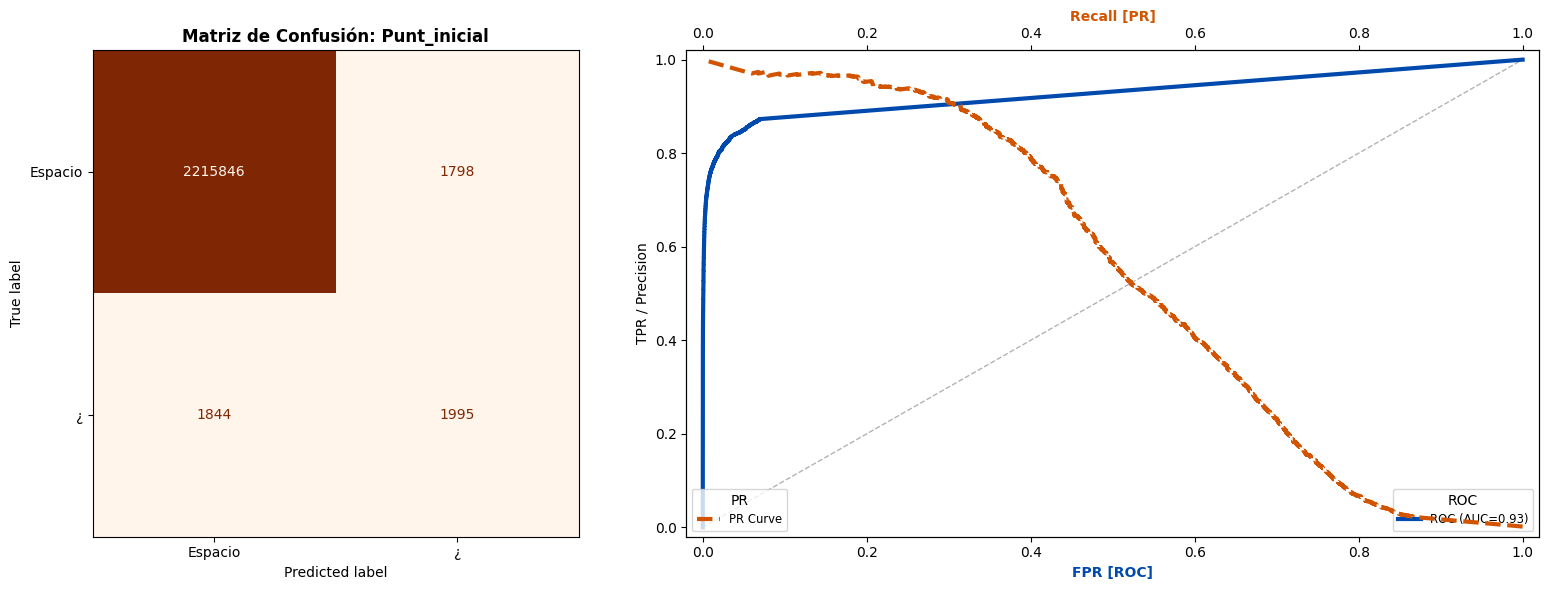

--------------------------------------------------------------------------------
Target: punt_final | Train: 8897451 | Test: 2221483

=== Grid Search y Entrenamiento Final: punt_final ===
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0, 'n_estimators': 150}
Mejor f1_macro (CV): 0.5350822236450401

--- Top 10 Features ---
            Feature  Importance
token_position_norm    0.122417
      emb_dist_next    0.116587
      emb_dist_prev    0.103737
    sentence_length    0.098516
   emb_cos_distance    0.097311
      is_last_token    0.096130
     token_position    0.084885
           token_id    0.064992
           emb_mean    0.060146
        emb_abs_sum    0.056297


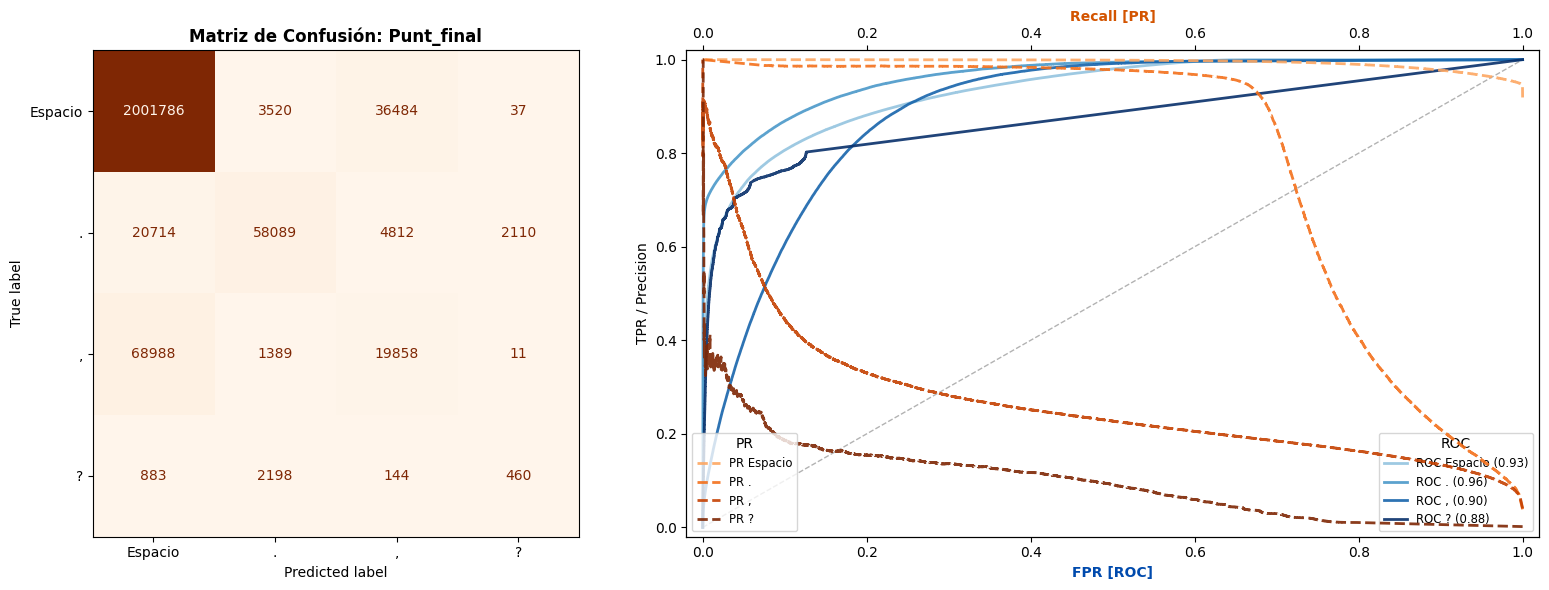

--------------------------------------------------------------------------------
Target: capitalizacion | Train: 8897451 | Test: 2221483

=== Grid Search y Entrenamiento Final: capitalizacion ===
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Mejores parámetros: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0, 'n_estimators': 150}
Mejor f1_macro (CV): 0.8020711887866947

--- Top 10 Features ---
            Feature  Importance
   emb_cos_distance    0.127502
         is_numeric    0.100109
            emb_std    0.099927
      emb_dist_prev    0.094104
        emb_abs_sum    0.090143
      emb_dist_next    0.080666
token_position_norm    0.076741
           token_id    0.069507
       token_length    0.065356
     token_position    0.063334


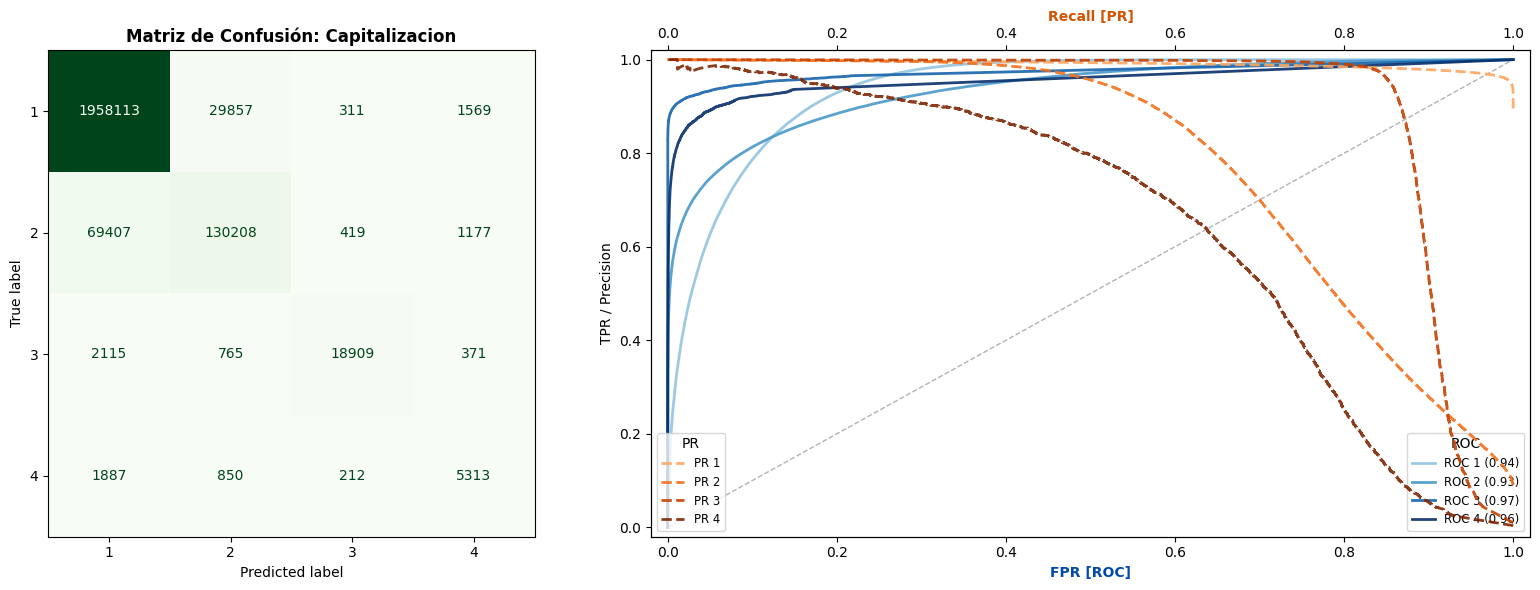

--------------------------------------------------------------------------------


In [15]:
# --- 3. EJECUCIÓN PRINCIPAL: ENTRENAMIENTO Y REPORTE ---
# Inicializamos variables para guardar modelos
best_estimators = {}
gs_results = {}
last_test_ids = None
rf_capitalizacion = None
rf_final = None
rf_inicial = None

print("\n" + "="*80 + "\n   INICIANDO PIPELINE COMPLETO\n" + "="*80)

for target in TARGET_COLS:
    # 1. División de Datos
    X_train, X_test, y_train, y_test, groups_train = split_by_instance(df_features, feature_names, target)

    # Guardar IDs de test para visualización cualitativa final
    if target == "capitalizacion":
        unique_train_ids = np.unique(groups_train)
        last_test_ids = df_features[~df_features["instancia_id"].isin(unique_train_ids)]["instancia_id"].unique()

    # 2. Grid Search (Entrenamiento definitivo)
    best_estimator, gs_res = grid_search_por_target_adaptado(X_train, y_train, groups_train, target)

    # 3. Guardado en variables globales
    best_estimators[target] = best_estimator
    gs_results[target] = gs_res

    if target == "capitalizacion": rf_capitalizacion = best_estimator
    elif target == "punt_final": rf_final = best_estimator
    elif target == "punt_inicial": rf_inicial = best_estimator

    # 4. Configuración de Etiquetas Visuales (Dinámico + Custom)
    # Obtenemos las clases reales que aprendió el modelo
    classes_present = best_estimator.classes_

    if target == "capitalizacion":
        is_multiclass = True
        # Etiquetas 1, 2, 3... desplazadas
        custom_labels = [str(c + 1) for c in classes_present]

    elif target == "punt_final":
        is_multiclass = True
        # Etiquetas reales del mapa
        raw_labels = [ID_TO_PUNT_FINAL.get(c, str(c)) for c in classes_present]
        custom_labels = ["Espacio" if l == "" else l for l in raw_labels]

    else: # punt_inicial
        is_multiclass = False
        custom_labels = ["Espacio", "¿"]

    # 5. Generar Reporte Gráfico Combinado
    get_feature_importance(best_estimator, feature_names)
    plot_combined_analysis(best_estimator, X_test, y_test, target.capitalize(), is_multiclass, custom_labels)
    print("-" * 80)

In [16]:
# --- 4. GUARDADO DE MODELOS Y EJEMPLOS ---
os.makedirs('saved_models', exist_ok=True)
modelos_guardar = {'rf_cap.pkl': rf_capitalizacion, 'rf_ini.pkl': rf_inicial, 'rf_fin.pkl': rf_final}
for name, model in modelos_guardar.items():
    with open(os.path.join('saved_models', name), 'wb') as f:
        pickle.dump(model, f)
print("\nModelos guardados exitosamente.")

# Función de Decodificación Visual
def decodificar(tokens, caps, inis, fins):
    out = []
    for i, t in enumerate(tokens):
        w = str(t)
        # Capitalización
        if caps[i]==0: w=w.lower()
        elif caps[i]==1: w=w.capitalize()
        elif caps[i]==3: w=w.upper()

        # Puntuación
        ini = inis[i] if pd.notna(inis[i]) and inis[i]!="" else ""
        fin = fins[i] if pd.notna(fins[i]) and fins[i]!="" else ""

        # Fusión sub-tokens
        if t.startswith("##") and out:
            prev = out.pop()
            out.append(prev + f"{ini}{w.replace('##','')}{fin}")
        else:
            out.append(f"{ini}{w}{fin}")
    return " ".join(out)

print("\n--- Visualización de Muestras (Test Set) ---")
if last_test_ids is not None:
    for idx in random.sample(list(last_test_ids), min(3, len(last_test_ids))):
        sub = df_features[df_features["instancia_id"] == idx]
        X_sub = sub[feature_names].values

        p_cap = rf_capitalizacion.predict(X_sub)
        p_ini = rf_inicial.predict(X_sub)
        p_fin = rf_final.predict(X_sub)

        # Decodificación
        real_ini = sub.punt_inicial.values
        real_fin = sub.punt_final.values

        pred_ini_dec = ["¿" if p==1 else "" for p in p_ini]
        pred_fin_dec = [ID_TO_PUNT_FINAL.get(p, "") for p in p_fin]

        real = decodificar(sub.token.values, sub.capitalizacion.values, real_ini, real_fin)
        pred = decodificar(sub.token.values, p_cap, pred_ini_dec, pred_fin_dec)

        print(f"ID {idx}:\nREAL: {real}\nPRED: {pred}\n{'-'*60}")


Modelos guardados exitosamente.

--- Visualización de Muestras (Test Set) ---
ID 233115:
REAL: Por lo tanto la costumbre no podrá ser más que fuente secundaria o supletoria de la ley.
PRED: Por lo tanto, la costumbre no podrá ser más que fuente secundaria o supletoria de la ley.
------------------------------------------------------------
ID 274589:
REAL: En primera instancia, el sistema nos pedirá que ingresemos alguna información nuestra como la escuela secundaria o la universidad en donde hemos estudiado, o el nombre de la empresa en la cual trabajamos.
PRED: En primera instancia, el sistema nos pedirá que ingresemos alguna información nuestra como la escuela secundaria o la Universidad en donde hemos estudiado o el nombre de la empresa en la cual trabajamos.
------------------------------------------------------------
ID 140655:
REAL: Debido a que NO hay prorrogas, es responsabilidad del interesado realizar correctamente el registro y concluirlo en las fechas establecidas en la co

# 10. Datos de testeo

In [48]:
path_test = "datos_test.csv"  # Asegúrate que este archivo exista en tu entorno
datos_test = pd.read_csv(path_test)
datos_test.head()

,instancia_id,token_id,token,punt_inicial,punt_final,capitalización
0,0,10109,la,NaN,NaN,NaN
1,0,67763,cuestión,NaN,NaN,NaN
2,0,10196,es,NaN,NaN,NaN
3,0,10121,que,NaN,NaN,NaN
4,0,10109,la,NaN,NaN,NaN


## Generación de predicciones para el test set (submission)

In [49]:

def generar_submission(model, model_name, tokenizer, path_test_csv):
    print(f"\n🚀 Iniciando proceso de inferencia sobre: {path_test_csv}")
    
    # 1. Cargar el CSV de Test
    # CORRECCIÓN: Leemos el archivo usando la ruta que nos pasan.
    try:
        df_test = pd.read_csv(path_test_csv)
    except Exception as e:
        print(f"❌ Error al leer el archivo: {e}")
        return

    print(f"   Filas cargadas: {len(df_test)}")
    
    # Aseguramos que los tokens sean strings
    df_test['token'] = df_test['token'].astype(str)
    
    # 2. Agrupar por instancia
    grouped = df_test.groupby('instancia_id')
    
    predicciones_pi = {}
    predicciones_pf = {}
    predicciones_cap = {}
    
    model.eval()
    
    inv_pi = {v: k for k, v in PUNTUACIONES_INICIALES.items()}
    inv_pf = {v: k for k, v in PUNTUACIONES_FINALES.items()}
    
    print("   Generando predicciones...")
    start = time.time()
    
    with torch.no_grad():
        for inst_id, group in grouped:
            tokens = group['token'].tolist()
            original_indices = group.index.tolist()
            
            # 3. Convertir Tokens a IDs (Directo, ya tokenizado)
            input_ids = tokenizer.convert_tokens_to_ids(tokens)
            
            x_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
            length = torch.tensor([len(input_ids)], dtype=torch.long)
            
            # 4. Inferencia
            logits_pi, logits_pf, logits_cap = model(x_tensor, length)
            
            preds_pi = torch.argmax(logits_pi, dim=2).squeeze(0).cpu().tolist()
            preds_pf = torch.argmax(logits_pf, dim=2).squeeze(0).cpu().tolist()
            preds_cap = torch.argmax(logits_cap, dim=2).squeeze(0).cpu().tolist()
            
            # 5. Guardar resultados
            for i, idx_df in enumerate(original_indices):
                predicciones_pi[idx_df] = inv_pi.get(preds_pi[i], "")
                predicciones_pf[idx_df] = inv_pf.get(preds_pf[i], "")
                predicciones_cap[idx_df] = preds_cap[i]

            if inst_id % 2500 == 0:
                print(f"   Procesado instancia {inst_id}...", end='\r')

    # 6. Escribir resultados
    print(f"\n   Asignando resultados al DataFrame...")
    df_test['punt_inicial'] = df_test.index.map(predicciones_pi)
    df_test['punt_final'] = df_test.index.map(predicciones_pf)
    df_test['capitalización'] = df_test.index.map(predicciones_cap)
    
    df_test['punt_inicial'].fillna("", inplace=True)
    df_test['punt_final'].fillna("", inplace=True)
    df_test['capitalización'].fillna(0, inplace=True)
    
    # 7. Guardar CSV
    cols_order = ['instancia_id', 'token_id', 'token', 'punt_inicial', 'punt_final', 'capitalización']
    final_cols = [c for c in cols_order if c in df_test.columns]
    df_final = df_test[final_cols]
    
    output_csv=f"submission_{model_name}.csv"

    df_final.to_csv(output_csv, index=False)
    print(f"✅ Archivo guardado: {output_csv} ({len(df_final)} filas)")
    print(f"⏱️ Tiempo total: {(time.time() - start):.2f}s")

#  Redefinir las constantes como Diccionarios (Mapeo: Símbolo -> ID de clase)
PUNTUACIONES_INICIALES = {"¿": 1}
PUNTUACIONES_FINALES = {".": 1, ",": 2, "?": 3}

## Función para visualizar resultados del csv de submission

In [50]:
def visualizar_desde_csv(csv_path, n_samples=5):
    """
    Lee el archivo de submission y reconstruye oraciones aleatorias para inspección visual.
    No requiere el modelo, solo el CSV generado.
    """
    if not os.path.exists(csv_path):
        print(f"⚠️ No se encontró el archivo {csv_path}")
        return

    print(f"\n{'='*100}")
    print(f"👀 INSPECCIONANDO ARCHIVO: {csv_path}")
    print(f"   Muestrando {n_samples} oraciones reconstruidas...")
    print(f"{'='*100}")

    df = pd.read_csv(csv_path)
    
    # Rellenar nulos por seguridad
    df.fillna({'punt_inicial': '', 'punt_final': '', 'capitalización': 0}, inplace=True)
    
    # Agrupar por instancia
    grupos = [g for _, g in df.groupby('instancia_id')]
    
    # Seleccionar aleatorios
    import random
    random.seed(42)
    muestras = random.sample(grupos, min(n_samples, len(grupos)))
    
    # Códigos ANSI (Mismos que usaste antes)
    ANSI_ITALIC = "\033[3m"
    ANSI_CYAN = "\033[96m"
    ANSI_RESET = "\033[0m"

    for i, grupo in enumerate(muestras):
        inst_id = grupo.iloc[0]['instancia_id']
        tokens = grupo['token'].astype(str).tolist()
        p_inis = grupo['punt_inicial'].tolist()
        p_fins = grupo['punt_final'].tolist()
        caps   = grupo['capitalización'].astype(int).tolist()
        
        oracion_reconstruida = []
        
        for j, token in enumerate(tokens):
            # 1. Aplicar estilo de Capitalización
            if caps[j] == 0:   # Lowercase
                t_str = token.lower()
            elif caps[j] == 1: # Titlecase
                t_str = token.capitalize()
            elif caps[j] == 2: # Mixed/Numbers (Cyan)
                t_str = f"{ANSI_ITALIC}{ANSI_CYAN}{token.capitalize()}{ANSI_RESET}"
            elif caps[j] == 3: # Upper
                t_str = token.upper()
            else:
                t_str = token
            
            # 2. Agregar Puntuación (Directamente del CSV)
            # El CSV ya tiene caracteres como "¿" o "", no hace falta diccionario inverso
            t_str = p_inis[j] + t_str + p_fins[j]
            
            # 3. Fusión de Sub-tokens (##)
            if token.startswith("##"):
                if oracion_reconstruida:
                    prev = oracion_reconstruida.pop()
                    fragmento = t_str.replace("##", "")
                    
                    # Lógica visual para mantener el color si se unen dos tokens coloreados
                    if prev.endswith(ANSI_RESET) and fragmento.startswith(ANSI_ITALIC):
                        prev = prev[:-len(ANSI_RESET)]
                        fragmento = fragmento[len(ANSI_ITALIC)+len(ANSI_CYAN):]
                    
                    oracion_reconstruida.append(prev + fragmento)
                else:
                    oracion_reconstruida.append(t_str.replace("##", ""))
            else:
                oracion_reconstruida.append(t_str)
        
        texto_final = " ".join(oracion_reconstruida)
        
        print(f"📄 ID: {inst_id}")
        print(f"🤖 {texto_final}")
        print("-" * 100)

## Testeo para RNN

In [51]:
model = model_RNN
model_name = 'multitask_RNN'
path_modelo = f'best_model_{model_name}.pt'

if os.path.exists(path_modelo):
    print(f"🔄 Cargando pesos guardados desde '{path_modelo}'...")
    
    # Cargar el state_dict (map_location asegura que funcione en CPU si se entrenó en GPU)
    state_dict = torch.load(path_modelo, map_location=device)
    
    # Cargar los pesos en la arquitectura ya instanciada
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval() # Poner en modo evaluación
    
    print(f"✅ Modelo {model_name} cargado exitosamente. Listo para inferencia.")
else:
    print(f"⚠️ No se encontró el archivo '{path_modelo}'. Debes entrenar el modelo primero.")

# --- EJECUTAR ---

path_test = "datos_test.csv"  # Asegúrate que este archivo exista en tu entorno
generar_submission(model, model_name, tokenizer, path_test)

🔄 Cargando pesos guardados desde 'best_model_multitask_RNN.pt'...
✅ Modelo multitask_RNN cargado exitosamente. Listo para inferencia.

🚀 Iniciando proceso de inferencia sobre: datos_test.csv
   Filas cargadas: 90828
   Generando predicciones...
   Procesado instancia 2500...
   Asignando resultados al DataFrame...
✅ Archivo guardado: submission_multitask_RNN.csv (90828 filas)
⏱️ Tiempo total: 4.21s


In [52]:
# --- EJECUTAR ---
visualizar_desde_csv(f"submission_{model_name}.csv", n_samples=80)


👀 INSPECCIONANDO ARCHIVO: submission_multitask_RNN.csv
   Muestrando 80 oraciones reconstruidas...
📄 ID: 2619
🤖 ¿Está muy cansado
----------------------------------------------------------------------------------------------------
📄 ID: 456
🤖 ¿Porque Bochornoso lamentable e irrespetuoso es que se cuestione a la consejera sobre las razones por las que mantiene al frente del metro. a alguien que ha demostrado sus limitaciones. gestoras y que ella responda a esa pregunta ponderando la puntualidad del metro.
----------------------------------------------------------------------------------------------------
📄 ID: 102
🤖 ¿y ley también aprobada por Aralar
----------------------------------------------------------------------------------------------------
📄 ID: 3037
🤖 No supo descifrar las huellas
----------------------------------------------------------------------------------------------------
📄 ID: 1126
🤖 Para que encaje mejor en esa nueva loapa
------------------------------------------

## Testeo para BRNN

In [53]:
#model = model_BRNN #para visualizar predicciones con BRNN

model = BRNN_LSTM(
    embedding_matrix=bert_embedding_matrix, 
    hidden_dim=HIDDEN_DIM, 
    n_pi=len(PUNTUACIONES_INICIALES)+1, # +1 por la clase 0
    n_pf=len(PUNTUACIONES_FINALES)+1, 
    n_cap=4, 
    dropout=DROPOUT
)

model_name = 'multitask_BRNN'
path_modelo = f'best_model_{model_name}.pt'

if os.path.exists(path_modelo):
    print(f"🔄 Cargando pesos guardados desde '{path_modelo}'...")
    
    # Cargar el state_dict (map_location asegura que funcione en CPU si se entrenó en GPU)
    state_dict = torch.load(path_modelo, map_location=device)
    
    # Cargar los pesos en la arquitectura ya instanciada
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval() # Poner en modo evaluación
    
    print(f"✅ Modelo {model_name} cargado exitosamente. Listo para inferencia.")
else:
    print(f"⚠️ No se encontró el archivo '{path_modelo}'. Debes entrenar el modelo primero.")

# --- EJECUTAR ---
path_test = "datos_test.csv"  # Asegúrate que este archivo exista en tu entorno
generar_submission(model, model_name, tokenizer, path_test)

🔄 Cargando pesos guardados desde 'best_model_multitask_BRNN.pt'...
✅ Modelo multitask_BRNN cargado exitosamente. Listo para inferencia.

🚀 Iniciando proceso de inferencia sobre: datos_test.csv
   Filas cargadas: 90828
   Generando predicciones...
   Procesado instancia 2500...
   Asignando resultados al DataFrame...
✅ Archivo guardado: submission_multitask_BRNN.csv (90828 filas)
⏱️ Tiempo total: 5.25s


In [54]:
# --- EJECUTAR ---
visualizar_desde_csv(f"submission_{model_name}.csv", n_samples=10)


👀 INSPECCIONANDO ARCHIVO: submission_multitask_BRNN.csv
   Muestrando 10 oraciones reconstruidas...
📄 ID: 2619
🤖 ¿Está muy cansado?
----------------------------------------------------------------------------------------------------
📄 ID: 456
🤖 Porque Bochornoso, lamentable e irrespetuoso es que se cuestione a la consejera sobre las razones por las que mantiene al frente del metro a alguien que ha demostrado sus limitaciones gestoras y que ella responda a esa pregunta, ponderando la puntualidad del metro.
----------------------------------------------------------------------------------------------------
📄 ID: 102
🤖 y ley también aprobada por Aralar.
----------------------------------------------------------------------------------------------------
📄 ID: 3037
🤖 ¿No supo descifrar las huellas.
----------------------------------------------------------------------------------------------------
📄 ID: 1126
🤖 ¿Para que encaje mejor en esa nueva loapa?
-------------------------------------

# Comparación F1 modelos

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparar los datos
data = {
    'Metric': ['F1: PI', 'F1: PF', 'F1: CAP'] * 3,
    'Score': [
        0.51, 0.535, 0.802,  # RF
        0.64, 0.45, 0.80,   # RNN
        0.70, 0.73, 0.87   # BRNN
    ],
    'Model': ['Random Forest'] * 3 + ['RNN'] * 3 + ['BRNN'] * 3
}
df_plot = pd.DataFrame(data)

# 2. Configurar el estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7)) # Ajuste de tamaño para las fuentes grandes

# 3. Definir paleta suave
soft_palette = ["#9b59b6", "#5dade2", "#e056fd"] 

# 4. Crear el gráfico
ax = sns.barplot(
    x="Model", 
    y="Score", 
    hue="Metric", 
    data=df_plot, 
    palette=soft_palette,
    alpha=0.7,
    edgecolor="white",
    linewidth=1.5
)

# 5. Añadir los valores con fuente GRANDE (16pt)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=16, fontweight='bold', color="dimgrey")

# 6. Ajustes de estilo
plt.ylim(0, 1.0)

# Etiquetas de ejes con fuente GRANDE (18pt)
plt.xlabel("Modelo", fontsize=18, color="dimgrey", fontweight='bold')
plt.ylabel("F1 Score", fontsize=18, color="dimgrey", fontweight='bold')

# Ticks con fuente GRANDE (16pt)
ax.tick_params(axis='both', which='major', labelsize=16, colors="dimgrey")

# Leyenda con fuente GRANDE (16pt)
plt.legend(
    title="Métrica", 
    title_fontsize=16, 
    fontsize=16, 
    loc='upper left', 
    bbox_to_anchor=(1, 1)
)

plt.tight_layout()
plt.show()
plt.savefig('comparacion_modelos_no_title_big_font.png', dpi=300)